## Basic ChatBot With Langgraph(Graph API)

In [3]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [5]:
graph_builder

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [50]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

In [51]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x73238afb9910>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x732391797dd0>, model_name='qwen/qwen3-32b', reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [52]:
#creating chatbot Node function
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [53]:
graph_builder=StateGraph(State)
#adding node
graph_builder.add_node("llmchatbot",chatbot)
#adding edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

In [54]:
#compile the graph
graph=graph_builder.compile()

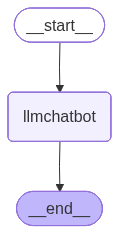

In [12]:
#visualize
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
responce=graph.invoke({"messages":"explain rest API"})

In [14]:
print(responce["messages"][-1].content)

<think>
Okay, I need to explain what a REST API is. Let me start by recalling what I know. REST stands for Representational State Transfer. It's an architectural style for designing networked applications. I remember that REST uses HTTP methods like GET, POST, PUT, DELETE. But why are those important?

So, REST APIs are about creating resources that can be accessed and manipulated over the web. Each resource is identified by a URI. For example, if I'm building a blog API, maybe the URI for a post would be something like /posts/123. The HTTP methods then act on these resources. GET would retrieve a resource, POST would create a new one, PUT would update, DELETE would remove it. That makes sense because those are common actions you do with resources.

Stateless is another key concept. The server doesn't keep any state between requests. Each request from the client must contain all the information needed to understand and process the request. So, the server doesn't store session informati

## CHATBOT with TOOL

In [15]:
import os 
import os
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("what is tavily?")

{'query': 'what is tavily?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://medium.com/@airabbitX/tavily-the-api-powered-alternative-to-perplexity-edfdc6814b39',
   'title': 'Tavily — The API-powered Alternative to Perplexity?',
   'content': '# Tavily — The API-powered Alternative to Perplexity? Perplexity is yet another fascinating innovation in the AI space, and it has been around for a while now. It has managed to establish itself as a real and imho better alternative to Google (even Google AI) by offering more control over the search itself (like choosing the model, the depth of the AI search, and so on). Although Perplexity does have an API, it is mainly for AI LLM inference. In its simplest form, the API should simply answer questions using internet search and AI. > With GPT Researcher, you can do exactly what you would expect: AI-powered research using facts from the internet or even on-premise documents, powered by LLMs. It has beco

In [17]:
def answer(query:str)->int:
    """ 
    answer multiplication of two numbers
    args :
    query : string type

    returns : 
    =int: output int 
    """


In [18]:
tools=[tool,answer]

In [19]:
llm_with_tools=llm.bind_tools(tools)

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x73239325e360>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7323930c6a80>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, a

In [21]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [22]:
#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools",END)

In [24]:
graph=builder.compile()

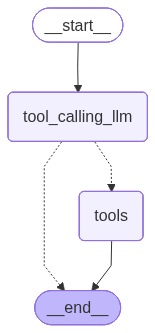

In [25]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
responce=graph.invoke({"messages":"what are latest AI news"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

what are latest AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (31m8wkmfb)
 Call ID: 31m8wkmfb
  Args:
    query: latest AI news
    search_depth: fast
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pcgamer.com/hardware/gaming-monitors/okay-maybe-i-could-be-convinced-ai-monitors-arent-all-bad/", "title": "Okay, maybe I could be convinced AI monitors aren't all bad - PC Gamer", "score": 1.0, "published_date": "Sun, 31 May 2026 11:58:00 GMT", "content": "See the latest gaming news first. For the quickest way to join, simply enter your email below and get access. We will send a confirmation and sign you up to our newsletter to keep 

In [27]:
responce=graph.invoke({"messages":"what is 3 multiplies 47"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

what is 3 multiplies 47
================================== Ai Message ==================================
Tool Calls:
  answer (c06wnf3x9)
 Call ID: c06wnf3x9
  Args:
    query: 3*47
================================= Tool Message =================================
Name: answer

null


## ReAct Agent Architecture

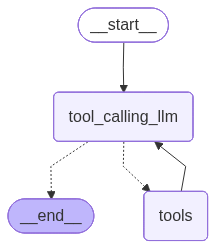

In [28]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools","tool_calling_llm")


graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
responce=graph.invoke({"messages":"what is the latest AI News and  3 multiplies 47"})
for i in responce["messages"]:
    i.pretty_print()

KeyboardInterrupt: 

## Adding Memory in Agentic Graph

In [31]:
responce=graph.invoke({"messages":"my name is rukus"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

my name is rukus
================================== Ai Message ==================================

Hello, Rukus! How can I assist you today?


In [ ]:
responce=graph.invoke({"messages":"what is my name"})
for i in responce["messages"]:
    i.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have access to personal information about users. If you'd like help with something specific, you can provide your name (or any other details) voluntarily. How can I assist you today?


In [73]:
tools_condition

<function langgraph.prebuilt.tool_node.tools_condition(state: 'list[AnyMessage] | dict[str, Any] | BaseModel', messages_key: 'str' = 'messages') -> "Literal['tools', '__end__']">

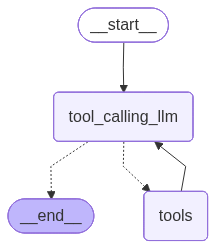

In [32]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
#node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
    )
builder.add_edge("tools","tool_calling_llm")


graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"1"}}
responce_after_adding_memory=graph.invoke({"messages":"my name is rukus"},config=config)
responce

{'messages': [HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='ddf4a66c-b801-4546-a61b-55470f2f5258'),
  AIMessage(content="I don't have access to personal information about users. If you'd like help with something specific, you can provide your name (or any other details) voluntarily. How can I assist you today?", additional_kwargs={'reasoning_content': 'Okay, the user is asking, "what is my name." Let me see how to approach this.\n\nFirst, I need to check if there\'s any function that can help. The available tools are tavily_search and answer. The answer function is for multiplying numbers, which doesn\'t apply here. The tavily_search is a search engine, but the user isn\'t asking for information that requires a web search. \n\nThe question is about the user\'s own name, which is a personal detail. Since the system doesn\'t have access to personal data unless provided, I can\'t retrieve that. I should inform the user that I don\'t have access to

In [ ]:
responce_after_adding_memory["messages"][-1].content

'Hello, Rukus! How can I assist you today?'

In [ ]:
responce_after_adding_memory=graph.invoke({"messages":"what is my name"},config=config)
responce_after_adding_memory["messages"][-1].content

'Hello again, Rukus! Your name is Rukus. How can I assist you today?'

In [30]:
responce_after_adding_memory=graph.invoke({"messages":"do you remember me"},config=config)
responce_after_adding_memory["messages"][-1].content

'Hello again, Rukus! Yes, I remember your name. How can I assist you today? 😊'

## Streaming

In [55]:
## Streaming techniques
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()


In [56]:
def SUPERBOT(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [57]:
graph_builder=StateGraph(State)
#adding node
graph_builder.add_node("llmchatbot",SUPERBOT)
#adding edge
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

In [58]:
graph=graph_builder.compile(checkpointer=memory)

In [59]:
config= {"configurable": {"thread_id":"1"}}
graph.invoke({"messages": " hey i like cricket"},config)

{'messages': [HumanMessage(content=' hey i like cricket', additional_kwargs={}, response_metadata={}, id='37a15eb1-87d6-47fc-b9af-15f8302a43ce'),
  AIMessage(content="That's awesome! Cricket is such an exciting sport with so many facets to enjoy. Whether it's the fast-paced T20s, the strategic depth of Test matches, or the blend of both in ODIs, there's something for everyone. 🏏\n\nWhat do you enjoy most about the game? Do you follow a particular team, format, or player? I'd love to hear what draws you to cricket! (And if you're up for it, we can chat about recent matches, legends like Virat Kohli or MS Dhoni, or even the ICC tournaments!)", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 327, 'prompt_tokens': 12, 'total_tokens': 339, 'completion_time': 0.7950187, 'completion_tokens_details': {'reasoning_tokens': 204}, 'prompt_time': 0.000282888, 'prompt_tokens_details': None, 'queue_time': 0.050194062, 'total_time': 0.795301588}, 'model_name': 'qwen/qwen3

In [63]:
config= {"configurable": {"thread_id":"2"}}
for chunk in graph.stream({"messages":"hi i am sampath"},config,stream_mode="updates"):
    print(chunk)

{'llmchatbot': {'messages': [AIMessage(content="Hello Sampath! 😊 Nice to see you again! I noticed you mentioned you're a good boy and love movies—what an awesome combo! 🎬✨ What’s your favorite movie or genre? If you ever want recommendations, trivia, or just to chat about your favorite films, I’m here to help! Let me know how I can assist. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 323, 'prompt_tokens': 216, 'total_tokens': 539, 'completion_time': 0.896893554, 'completion_tokens_details': {'reasoning_tokens': 244}, 'prompt_time': 0.009281219, 'prompt_tokens_details': None, 'queue_time': 0.052036191, 'total_time': 0.906174773}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e8200-981f-7ab0-8de9-ffe449b0c502-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 216, 'output_tokens': 323, 'total

In [64]:
config= {"configurable": {"thread_id":"2"}}
for chunk in graph.stream({"messages":"hi i am sampath, i am agood bou and i like movies "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi i am sampath', additional_kwargs={}, response_metadata={}, id='44e8ff2b-1335-47aa-ba90-70a494c39287'), AIMessage(content="Hi Sampath! 👋 Nice to meet you! How can I assist you today? Feel free to ask any questions or share what you'd like help with. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 13, 'total_tokens': 123, 'completion_time': 0.227605043, 'completion_tokens_details': {'reasoning_tokens': 71}, 'prompt_time': 0.000718344, 'prompt_tokens_details': None, 'queue_time': 0.051137106, 'total_time': 0.228323387}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e81fe-0802-7603-a3bd-314c5eadb14c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 110, 'total_tokens': 123, 'output_token_details': {'reasoning': 71}}

In [66]:
config= {"configurable": {"thread_id":"6"}}
async for chunk in graph.astream_events({"messages":"hi i am sampath, i am agood bou and i like movies "},config,stream_mode="values"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hi i am sampath, i am agood bou and i like movies '}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e8204-8ab2-7283-9c4d-8b5560ad2e87', 'metadata': {'thread_id': '6', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019e8204-8ab2-7283-9c4d-8b5560ad2e87', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '6', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='hi i am sampath, i am agood bou and i like movies ', additional_kwargs={}, response_metadata={}, id='75e04923-cf68-490c-b453-504d3f54797f')]}}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi i am sampath, i am agood bou and i like movies ', additional_kwargs={}, response_metadata={}, id='75e04923-cf68-490c-b453-504d3f54797f')]}}, 'name': 'llmchatbot', 'tags': ['graph:step:1'], 'run_id': '019e8204-8ab3-7a50-813e-14198c6f3954', 'metad

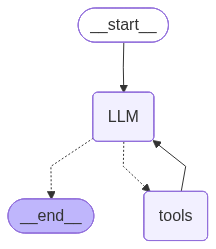

In [88]:
from langchain_community.tools import DuckDuckGoSearchRun
# from langchain.messages import add_messages
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph import START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition


def web_search(query):
    """
    Search on Web about any concept
    """
    search = DuckDuckGoSearchRun()
    return search.run(query)

tools = [web_search]

llm = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")
llm = llm.bind_tools(tools)


def my_llm(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

# graph_builder.add_node(START)
graph_builder.add_node("LLM", my_llm)
graph_builder.add_node(
    "tools",
    ToolNode(tools),
)
# graph_builder.add_node(END)

graph_builder.add_edge(START, "LLM")
graph_builder.add_conditional_edges(
    "LLM",
    tools_condition
)
graph_builder.add_edge("tools", "LLM")
graph_builder.add_edge("LLM", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
final = None
for chunk in graph.stream({"messages": "Explain OpenClaw"}, stream_mode="values"):
    final = chunk
    print(chunk)

{'messages': [HumanMessage(content='Explain OpenClaw', additional_kwargs={}, response_metadata={}, id='f30102f2-6058-4756-948b-ca0c19d47d34')]}
{'messages': [HumanMessage(content='Explain OpenClaw', additional_kwargs={}, response_metadata={}, id='f30102f2-6058-4756-948b-ca0c19d47d34'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 't7p21jajb', 'function': {'arguments': '{"query":"OpenClaw"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 289, 'prompt_tokens': 146, 'total_tokens': 435, 'completion_time': 0.634465283, 'completion_tokens_details': {'reasoning_tokens': 264}, 'prompt_time': 0.006487554, 'prompt_tokens_details': None, 'queue_time': 0.157242525, 'total_time': 0.640952837}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e822b-3bc4-7d82-be00-04c2ff337ac3-0', tool_c

In [97]:
from IPython.display import Markdown
Markdown(final["messages"][-1].content)

OpenClaw is a **free, open-source AI assistant** designed to run locally on your devices, allowing users to automate tasks and interact with large language models (LLMs) like Claude or GPT across multiple messaging and collaboration platforms. Key features include:

1. **Self-Hosted & Privacy-Focused**: You control the AI, ensuring data privacy as it runs on your hardware rather than cloud services.  
2. **Multi-Platform Integration**: Connects to WhatsApp, Telegram, Discord, Slack, Signal, and over 30 other platforms via built-in or plugin-based channels.  
3. **Task Automation**: Execute tasks using LLMs or local AI models, such as answering messages, generating content, or triggering scripts.  
4. **Unified Interface**: Acts as a gateway to manage interactions across your preferred apps, with support for voice, text, and live Canvas rendering (e.g., for visual outputs).  

Developed by Peter Steinberger (known for his work in open-source projects), OpenClaw emphasizes flexibility and customization. The confusion in search results likely stems from a separate project (a 1997 game reimplementation), but the active OpenClaw is the AI assistant with over 310k GitHub stars.  

For more details, check its [GitHub repository](https://github.com/petersteinberger/openclaw).